In [37]:
# Neural Style Transfer using Deep Learning

In [39]:
## Project Overview
...

In [ ]:
pip install tensorflow matplotlib numpy pillow

In [41]:
## Load Images

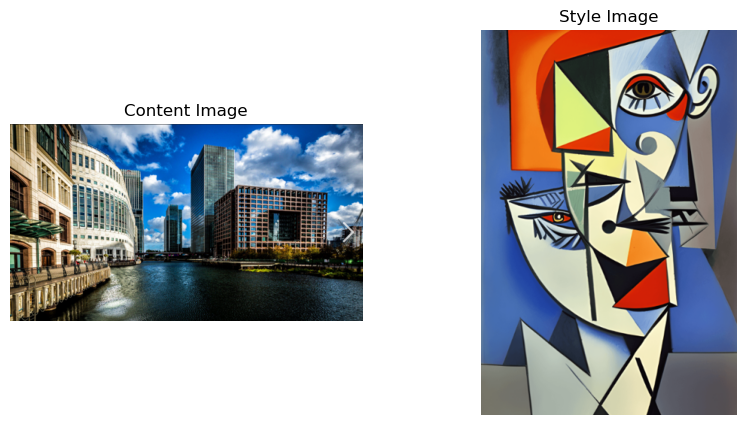

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Load image function
def load_image(path, max_dim=512):
    img = Image.open(path)
    
    # Resize image
    long = max(img.size)
    scale = max_dim / long
    img = img.resize((int(img.size[0]*scale), int(img.size[1]*scale)))
    
    img = np.array(img)
    img = tf.convert_to_tensor(img, dtype=tf.float32)
    
    img = img[tf.newaxis, :]
    return img

# Load images
content_image = load_image("content.jpg")
style_image = load_image("style.jpg")

# Display function
def show_image(image, title=None):
    image = tf.squeeze(image)
    image = tf.cast(image, tf.uint8)
    
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis("off")

# Show images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
show_image(content_image, "Content Image")

plt.subplot(1,2,2)
show_image(style_image, "Style Image")

plt.show()

In [43]:
## Load VGG19 Model

In [5]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input

# Load VGG19 model
vgg = VGG19(include_top=False, weights='imagenet')

# Freeze model (no training)
vgg.trainable = False

# Print model summary (optional)
vgg.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step


Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, None, None, 3)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, None, None, 64)      │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, None, None, 64)      │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, None, None, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, None, None, 128)     │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, None, None, 128)     │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, None, None, 128)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, None, None, 256)     │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, None, None, 256)     │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, None, None, 256)     │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, None, None, 256)     │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, None, None, 256)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, None, None, 512)     │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, None, None, 512)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,024,384 (76.39 MB)

In [7]:
# Content layer
content_layers = ['block5_conv2']

# Style layers
style_layers = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

In [45]:
## Feature Extraction

In [9]:
def get_model():
    outputs = [vgg.get_layer(name).output for name in style_layers + content_layers]
    model = tf.keras.Model([vgg.input], outputs)
    return model

model = get_model()

In [11]:
def preprocess_image(image):
    image = tf.image.resize(image, (224, 224))
    return preprocess_input(image)

In [13]:
# Preprocess images
content_input = preprocess_image(content_image)
style_input = preprocess_image(style_image)

# Get outputs
outputs = model(content_input)

# Split outputs
style_outputs = outputs[:len(style_layers)]
content_outputs = outputs[len(style_layers):]

In [47]:
## Loss Functions

In [15]:
def content_loss(base, target):
    return tf.reduce_mean(tf.square(base - target))

In [17]:
def gram_matrix(input_tensor):
    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
    shape = tf.shape(input_tensor)
    num_locations = tf.cast(shape[1]*shape[2], tf.float32)
    return result / num_locations

In [19]:
def style_loss(base, target):
    return tf.reduce_mean(tf.square(gram_matrix(base) - gram_matrix(target)))

In [21]:
content_weight = 1e4
style_weight = 1e-2

def total_loss(outputs, content_targets, style_targets):
    style_outputs = outputs[:len(style_layers)]
    content_outputs = outputs[len(style_layers):]

    c_loss = tf.add_n([content_loss(c, t) for c, t in zip(content_outputs, content_targets)])
    s_loss = tf.add_n([style_loss(s, t) for s, t in zip(style_outputs, style_targets)])

    total = content_weight * c_loss + style_weight * s_loss
    return total

In [23]:
# Extract targets
style_targets = model(style_input)[:len(style_layers)]
content_targets = model(content_input)[len(style_layers):]

In [49]:
## Optimization

In [25]:
generated_image = tf.Variable(content_input)

In [27]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.02)

In [29]:
@tf.function
def train_step(image):
    with tf.GradientTape() as tape:
        outputs = model(image)
        loss = total_loss(outputs, content_targets, style_targets)

    gradients = tape.gradient(loss, image)
    optimizer.apply_gradients([(gradients, image)])
    
    image.assign(tf.clip_by_value(image, -103.939, 151.061))
    
    return loss

In [31]:
import time

epochs = 10
steps_per_epoch = 50

for epoch in range(epochs):
    start = time.time()
    
    for step in range(steps_per_epoch):
        loss = train_step(generated_image)

    print(f"Epoch {epoch+1}, Loss: {loss.numpy()}, Time: {time.time()-start:.2f}s")

Epoch 1, Loss: 6556944384.0, Time: 37.54s
Epoch 2, Loss: 5926175744.0, Time: 36.28s
Epoch 3, Loss: 5339584000.0, Time: 36.40s
Epoch 4, Loss: 4804867584.0, Time: 38.36s
Epoch 5, Loss: 4327819776.0, Time: 40.04s
Epoch 6, Loss: 3905978368.0, Time: 48.42s
Epoch 7, Loss: 3538880768.0, Time: 48.74s
Epoch 8, Loss: 3220333056.0, Time: 41.15s
Epoch 9, Loss: 2947381760.0, Time: 40.31s
Epoch 10, Loss: 2712492288.0, Time: 43.34s


In [51]:
## Results

(-0.5, 223.5, 223.5, -0.5)

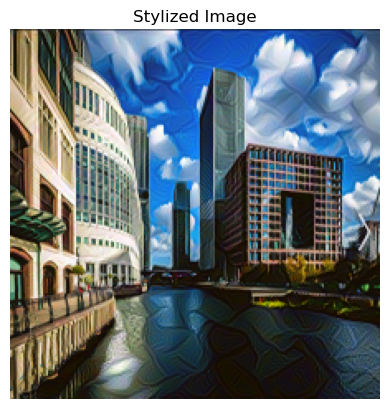

In [32]:
def deprocess(image):
    image = image.numpy().squeeze()
    image[:, :, 0] += 103.939
    image[:, :, 1] += 116.779
    image[:, :, 2] += 123.68
    image = image[:, :, ::-1]
    return np.clip(image, 0, 255).astype('uint8')

plt.imshow(deprocess(generated_image))
plt.title("Stylized Image")
plt.axis("off")

In [35]:
from PIL import Image

Image.fromarray(deprocess(generated_image)).save("output.jpg")